# 📈 Predicción de Serie Temporal con Perceptrón Multicapa (MLP)
## Dataset: Tipo de Cambio MXN/USD — DEXMXUS (FRED)

---

En este notebook aplicamos un **Perceptrón Multicapa (MLP)** para predecir valores futuros
del tipo de cambio entre el **Peso Mexicano (MXN)** y el **Dólar Estadounidense (USD)**.

El dataset proviene del **Federal Reserve Economic Data (FRED)** e incluye cotizaciones
**diarias desde 1993** hasta la actualidad, cubriendo más de 30 años con miles de registros
que abarcan múltiples ciclos económicos, crisis financieras y temporadas cambiarias.

### ¿Por qué este dataset?
-  Más de **30 años** de datos diarios (~8000 registros)
-  Incluye crisis económicas: **1994 (Tequilazo), 2008 (crisis global), 2020 (COVID)**
-  Presenta tendencias, estacionalidades y alta variabilidad
-  Fuente confiable: **Federal Reserve Bank of St. Louis**

### Estructura del notebook:
1. Descarga e instalación
2. Importación de librerías
3. Carga y exploración del dataset
4. Preprocesamiento y normalización
5. Construcción de ventanas deslizantes
6. División Train / Validación / Test
7. Dataset y DataLoader (PyTorch)
8. Predicción Naive (baseline)
9. Modelo MLP
10. Entrenamiento
11. Evaluación: MSE, RMSE, MAE
12. Gráficas de predicción vs real
13. Conclusiones

In [14]:
# Descargamos el dataset completo desde FRED (1993 hasta hoy)
# Esto nos da ~8000 registros de cotizaciones diarias MXN/USD
import urllib.request

url = 'https://fred.stlouisfed.org/graph/fredgraph.csv?id=DEXMXUS'
urllib.request.urlretrieve(url, '/content/DEXMXUS.csv')
print('✅ Dataset completo descargado en /content/DEXMXUS.csv')

✅ Dataset completo descargado en /content/DEXMXUS.csv


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Fijamos semillas para reproducibilidad de resultados
np.random.seed(42)
torch.manual_seed(42)

# Detectar si hay GPU disponible, si no usar CPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'

print('✅ Librerías importadas correctamente')
print(f'🔧 PyTorch versión : {torch.__version__}')
print(f'💻 Dispositivo     : {device}')

✅ Librerías importadas correctamente
🔧 PyTorch versión : 2.10.0+cpu
💻 Dispositivo     : cpu


## 3. 📂 Carga y Exploración del Dataset

Cargamos el archivo `DEXMXUS.csv` descargado desde FRED.

**Consideraciones importantes:**
- Los días festivos no tienen cotización → FRED los representa con `.` → los tratamos como `NaN` y los eliminamos
- La columna de fecha en FRED se llama `observation_date` → la renombramos a `DATE`
- Ordenamos cronológicamente para respetar el orden temporal de la serie

In [16]:
# Cargamos el CSV — na_values='.' para tratar los días sin cotización como NaN
df = pd.read_csv('/content/DEXMXUS.csv', na_values='.', parse_dates=['observation_date'])

# Renombramos la columna de fecha para mayor claridad
df = df.rename(columns={'observation_date': 'DATE'})

# Eliminamos filas con valores nulos y ordenamos cronológicamente
df = df.dropna().sort_values('DATE').reset_index(drop=True)

print(f'📊 Total de registros (días hábiles): {len(df)}')
print(f'📅 Desde : {df["DATE"].min().date()}')
print(f'📅 Hasta : {df["DATE"].max().date()}')
print(f'\n📋 Estadísticas descriptivas:')
print(df['DEXMXUS'].describe())

📊 Total de registros (días hábiles): 8103
📅 Desde : 1993-11-08
📅 Hasta : 2026-03-06

📋 Estadísticas descriptivas:
count    8103.000000
mean       13.260580
std         4.736493
min         3.102200
25%         9.787750
50%        12.462500
75%        18.149500
max        25.132000
Name: DEXMXUS, dtype: float64


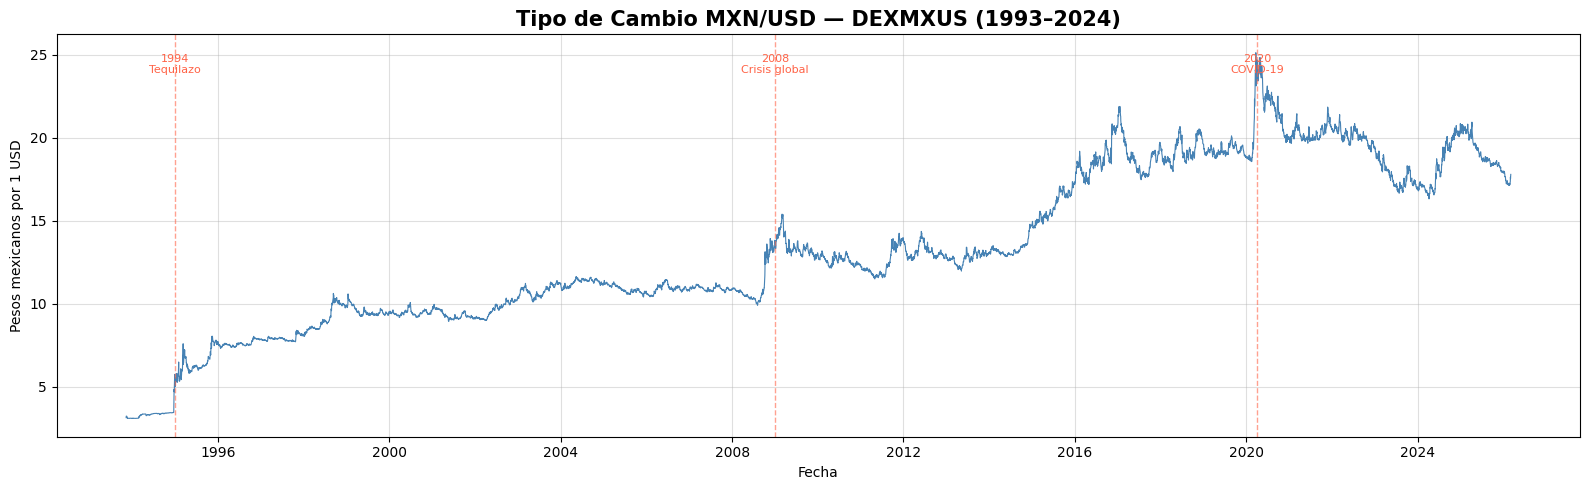


📌 Observaciones:
  • Tendencia general al alza (depreciación del peso frente al dólar).
  • Las crisis se reflejan como picos bruscos de depreciación.
  • La volatilidad aumenta en períodos de incertidumbre económica.


In [17]:
plt.figure(figsize=(16, 5))
plt.plot(df['DATE'], df['DEXMXUS'], color='steelblue', linewidth=0.8)
plt.title('Tipo de Cambio MXN/USD — DEXMXUS (1993–2024)', fontsize=15, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Pesos mexicanos por 1 USD')
plt.grid(True, alpha=0.4)

# Marcamos las principales crisis económicas
crisis = {
    '1994\nTequilazo' : '1995-01-01',
    '2008\nCrisis global' : '2009-01-01',
    '2020\nCOVID-19' : '2020-04-01'
}
for label, fecha in crisis.items():
    plt.axvline(pd.to_datetime(fecha), color='tomato', linestyle='--', alpha=0.6, linewidth=1)
    plt.text(pd.to_datetime(fecha), df['DEXMXUS'].max() * 0.95, label,
             fontsize=8, color='tomato', ha='center')

plt.tight_layout()
plt.show()

print('\n📌 Observaciones:')
print('  • Tendencia general al alza (depreciación del peso frente al dólar).')
print('  • Las crisis se reflejan como picos bruscos de depreciación.')
print('  • La volatilidad aumenta en períodos de incertidumbre económica.')

## 4. 🔄 Preprocesamiento y Normalización

Las redes neuronales son sensibles a la **escala de los datos**. Si los valores son
muy grandes o tienen rangos distintos, el entrenamiento puede volverse inestable.

Usamos **MinMaxScaler** que transforma todos los valores al rango **[0, 1]**:

$$x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

> ⚠️ **Regla clave:** el scaler se ajusta (`fit`) **únicamente con datos de entrenamiento**
> y luego se aplica (`transform`) a toda la serie. Esto evita el *data leakage*,
> que ocurre cuando información del futuro contamina el modelo durante el entrenamiento.

In [19]:
# Extraemos los valores de cotización como array NumPy
values = df['DEXMXUS'].values.astype(np.float32)

# Total de registros
n = len(values)

# Definimos los cortes cronológicos ANTES de normalizar
train_end = int(n * 0.70)   # 70% → entrenamiento
val_end   = int(n * 0.85)   # 15% → validación  (el 15% restante = test)

# Ajustamos el scaler SOLO con los datos de entrenamiento
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(values[:train_end].reshape(-1, 1))

# Aplicamos la transformación a TODA la serie
scaled = scaler.transform(values.reshape(-1, 1)).flatten().astype(np.float32)

print('✅ Normalización completada.')
print(f'   Valor mínimo original : {values.min():.4f} MXN  →  Normalizado: {scaled.min():.4f}')
print(f'   Valor máximo original : {values.max():.4f} MXN  →  Normalizado: {scaled.max():.4f}')
print(f'\n   Registros totales     : {n}')
print(f'   Corte entrenamiento   : {train_end}  (hasta índice {train_end-1})')
print(f'   Corte validación      : {val_end}    (hasta índice {val_end-1})')
print(f'   Test                  : {n - val_end} registros')


✅ Normalización completada.
   Valor mínimo original : 3.1022 MXN  →  Normalizado: 0.0000
   Valor máximo original : 25.1320 MXN  →  Normalizado: 1.3691

   Registros totales     : 8103
   Corte entrenamiento   : 5672  (hasta índice 5671)
   Corte validación      : 6887    (hasta índice 6886)
   Test                  : 1216 registros


```

```
## 5. 🪟 Construcción de Ventanas Deslizantes

Para aplicar el MLP a una serie temporal, transformamos la secuencia en pares
de **entrada → salida** usando la técnica de **ventana deslizante** (*sliding window*):
```
Día:  1   2   3  ...  50  |  51   ← predecir este
      [  Entrada X (50 valores)  ]  [y]

Día:  2   3   4  ...  51  |  52   ← predecir este
      [  Entrada X (50 valores)  ]  [y]
...
```

- **Entrada (X):** los últimos `n_steps = 50` días de cotización
- **Salida (y):** el valor del día siguiente

Con `n_steps = 50` estamos usando aproximadamente **2 meses bursátiles** de historia
para predecir cada valor, lo que le da al modelo suficiente contexto de tendencia reciente.

Esta lógica replica exactamente el cuadernillo del docente:
```python
X_train, y_train = series[:7000, :n_steps], series[:7000, -1]
```

In [20]:
n_steps = 50  # Ventana de 50 días hábiles (~2 meses bursátiles)

X_all, y_all = [], []

for i in range(len(scaled) - n_steps):
    X_all.append(scaled[i : i + n_steps])    # 50 días como entrada
    y_all.append(scaled[i + n_steps])         # día 51 como salida

X_all = np.array(X_all, dtype=np.float32)              # forma: (N, 50)
y_all = np.array(y_all, dtype=np.float32).reshape(-1, 1)  # forma: (N, 1)

print(f'✅ Ventanas deslizantes creadas correctamente.')
print(f'   Total de muestras : {X_all.shape[0]}')
print(f'   Forma de X        : {X_all.shape}  → cada fila es una ventana de {n_steps} días')
print(f'   Forma de y        : {y_all.shape}  → cada fila es el día siguiente a predecir')


✅ Ventanas deslizantes creadas correctamente.
   Total de muestras : 8053
   Forma de X        : (8053, 50)  → cada fila es una ventana de 50 días
   Forma de y        : (8053, 1)  → cada fila es el día siguiente a predecir


```


```
## 6. ✂️ División Train / Validación / Test

Dividimos el dataset de forma **cronológica** — nunca aleatoria en series temporales.

> Hacerlo aleatoriamente sería una trampa: estaríamos usando datos del futuro
> para predecir el pasado, lo que infla artificialmente las métricas.

| Conjunto       | Proporción | Registros aprox. | Uso                                     |
|----------------|------------|------------------|-----------------------------------------|
| **Train**      | 70 %       | ~5500            | Ajuste de pesos del modelo              |
| **Validación** | 15 %       | ~1100            | Monitoreo y detección de sobreajuste    |
| **Test**       | 15 %       | ~1100            | Evaluación final (nunca visto por el modelo) |

In [21]:
N         = len(X_all)
train_end = int(N * 0.70)
val_end   = int(N * 0.85)

X_train, y_train = X_all[:train_end],        y_all[:train_end]
X_valid, y_valid = X_all[train_end:val_end], y_all[train_end:val_end]
X_test,  y_test  = X_all[val_end:],          y_all[val_end:]

print(f'📁 División del dataset:')
print(f'   🟢 Train      : {X_train.shape[0]:>5} muestras  ({X_train.shape[0]/N*100:.1f}%)')
print(f'   🟡 Validación : {X_valid.shape[0]:>5} muestras  ({X_valid.shape[0]/N*100:.1f}%)')
print(f'   🔴 Test       : {X_test.shape[0]:>5} muestras  ({X_test.shape[0]/N*100:.1f}%)')
print(f'   ─────────────────────────────────────')
print(f'   Total         : {N:>5} muestras')


📁 División del dataset:
   🟢 Train      :  5637 muestras  (70.0%)
   🟡 Validación :  1208 muestras  (15.0%)
   🔴 Test       :  1208 muestras  (15.0%)
   ─────────────────────────────────────
   Total         :  8053 muestras


```
```
## 7. 🔁 Dataset y DataLoader (PyTorch)

Replicamos exactamente la clase `TimeSeriesDataset` del cuadernillo del docente.

Esta clase hereda de `torch.utils.data.Dataset` y cumple dos funciones:
- `__len__`: devuelve el número total de muestras
- `__getitem__`: devuelve una muestra individual dado su índice

El `DataLoader` se encarga de:
- Agrupar muestras en **mini-batches** de 64
- **Mezclar** (`shuffle=True`) los datos de entrenamiento en cada época
- Servir los batches de forma eficiente durante el entrenamiento

In [22]:
class TimeSeriesDataset(Dataset):
    """
    Dataset personalizado para series temporales con ventana deslizante.
    - train=True  → devuelve (X, y) para entrenamiento y validación
    - train=False → devuelve solo X para inferencia en test
    """
    def __init__(self, X, y=None, train=True):
        self.X     = X
        self.y     = y
        self.train = train

    def __len__(self):
        return len(self.X)

    def __getitem__(self, ix):
        if self.train:
            return torch.from_numpy(self.X[ix]), torch.from_numpy(self.y[ix])
        return torch.from_numpy(self.X[ix])


# Creamos los datasets
dataset = {
    'train': TimeSeriesDataset(X_train, y_train, train=True),
    'eval' : TimeSeriesDataset(X_valid, y_valid, train=True),
    'test' : TimeSeriesDataset(X_test,            train=False)
}

# Creamos los dataloaders
dataloader = {
    'train': DataLoader(dataset['train'], shuffle=True,  batch_size=64),
    'eval' : DataLoader(dataset['eval'],  shuffle=False, batch_size=64),
    'test' : DataLoader(dataset['test'],  shuffle=False, batch_size=64)
}

print('✅ Dataset y DataLoaders creados correctamente.')
print(f'   Batch size         : 64')
print(f'   Batches en train   : {len(dataloader["train"])}')
print(f'   Batches en eval    : {len(dataloader["eval"])}')
print(f'   Batches en test    : {len(dataloader["test"])}')


✅ Dataset y DataLoaders creados correctamente.
   Batch size         : 64
   Batches en train   : 89
   Batches en eval    : 19
   Batches en test    : 19


```

```
## 8. 🎯 Predicción Naive (Baseline)

Antes de entrenar el MLP, establecemos un modelo **baseline** extremadamente simple:
predecir que el valor del día siguiente es exactamente igual al último día conocido.
```
ŷ(t+1) = x(t)
```

Este modelo es sorprendentemente competitivo en series financieras porque los precios
tienen alta **autocorrelación** (el precio de hoy se parece mucho al de ayer).

**¿Para qué sirve?**  
Si nuestro MLP no supera este baseline, significa que el modelo **no está aprendiendo
nada útil** y necesita ajustes. Es el piso mínimo de rendimiento aceptable.

In [23]:
# Predicción naive: el último valor de la ventana es la predicción
y_pred_naive = X_test[:, -1].reshape(-1, 1)

# Desnormalizamos para calcular métricas en escala real (MXN/USD)
y_test_real  = scaler.inverse_transform(y_test)
y_naive_real = scaler.inverse_transform(y_pred_naive)

# Calculamos las tres métricas
mse_naive  = mean_squared_error(y_test_real, y_naive_real)
rmse_naive = np.sqrt(mse_naive)
mae_naive  = mean_absolute_error(y_test_real, y_naive_real)

print('📊 Métricas del modelo NAIVE (escala real MXN/USD):')
print(f'   MSE  : {mse_naive:.6f}')
print(f'   RMSE : {rmse_naive:.6f}  pesos/dólar de error promedio')
print(f'   MAE  : {mae_naive:.6f}  pesos/dólar de error promedio')
print()
print('📌 Estas métricas son el piso mínimo que el MLP debe superar.')


📊 Métricas del modelo NAIVE (escala real MXN/USD):
   MSE  : 0.017301
   RMSE : 0.131533  pesos/dólar de error promedio
   MAE  : 0.096387  pesos/dólar de error promedio

📌 Estas métricas son el piso mínimo que el MLP debe superar.


```

```
## 9. 🧠 Modelo MLP — Perceptrón Multicapa

Usamos:
```python
class MLP(torch.nn.Module):
    def __init__(self, n_in=50, n_out=1):
        super().__init__()
        self.fc = torch.nn.Linear(n_in, n_out)

    def forward(self, x):
        x = x.view(x.shape[0], -1)
        x = self.fc(x)
        return x
```

### ¿Qué hace este modelo?
- **Recibe** los 50 valores de la ventana **aplanados** como un vector
- Una única **capa lineal** `nn.Linear(50, 1)` produce la predicción
- **51 parámetros** en total: 50 pesos (uno por día) + 1 bias
- El modelo aprende **qué combinación lineal** de los 50 días anteriores
  predice mejor el día siguiente

### Diferencia con la RNN (según el docente):
El MLP recibe los 50 valores **todos a la vez y en paralelo**, sin considerar
el orden temporal. La RNN los recibiría **uno por uno**, conservando el orden.

In [24]:
class MLP(torch.nn.Module): #Perceptrón Multicapa para predicción de series temporales.
#Entrada : secuencia aplanada de n_in pasos temporales Salida
#: el siguiente valor de la serie (regresión escalar)

    def __init__(self, n_in=50, n_out=1):
        super().__init__()
        self.fc = torch.nn.Linear(n_in, n_out)

    def forward(self, x):
        x = x.view(x.shape[0], -1)  # aplanar: (batch, 50)
        x = self.fc(x)               # capa lineal → (batch, 1)
        return x


# Instanciamos el modelo con ventana de 50 días
mlp = MLP(n_in=n_steps, n_out=1)

print(mlp)
print(f'\n🔢 Parámetros totales : {sum(p.numel() for p in mlp.parameters())}')
print(f'   Pesos : {mlp.fc.weight.shape}  →  {mlp.fc.weight.numel()} valores')
print(f'   Bias  : {mlp.fc.bias.shape}    →  {mlp.fc.bias.numel()} valor')


MLP(
  (fc): Linear(in_features=50, out_features=1, bias=True)
)

🔢 Parámetros totales : 51
   Pesos : torch.Size([1, 50])  →  50 valores
   Bias  : torch.Size([1])    →  1 valor


```
```
## 10. 🏋️ Entrenamiento del MLP

funciones `fit()` y `predict()`.

### ¿Cómo aprende el modelo? (por época)
1. **Forward pass** → el modelo genera predicciones con los pesos actuales
2. **Loss (MSELoss)** → se mide el error cuadrático medio entre predicción y real
3. **Backward pass** → se calculan los gradientes con `loss.backward()`
4. **Adam optimizer** → actualiza los pesos en dirección al mínimo del error
5. Se evalúa en validación con `torch.no_grad()` para no actualizar pesos

### Hiperparámetros:
| Parámetro     | Valor  | Justificación                              |
|---------------|--------|--------------------------------------------|
| Optimizer     | Adam   | Adaptativo, converge bien en series financieras |
| Learning rate | 1e-3   | Valor estándar del cuadernillo del docente |
| Loss          | MSELoss| Regresión escalar                          |
| Batch size    | 64     | Balance entre velocidad y estabilidad      |
| Épocas        | 50     | Suficiente para convergencia               |

In [25]:
def fit(model, dataloader, epochs=50):
    """
    Entrena el modelo y monitorea la pérdida en validación.
    Retorna el historial de pérdidas para graficar la curva de aprendizaje.
    """
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = torch.nn.MSELoss()
    history   = {'train_loss': [], 'val_loss': []}

    bar = tqdm(range(1, epochs + 1))
    for epoch in bar:

        # ── Fase de entrenamiento ─────────────────────────────────────────
        model.train()
        train_loss = []
        for batch in dataloader['train']:
            X, y = batch
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()        # limpiar gradientes anteriores
            y_hat = model(X)             # predicción
            loss  = criterion(y_hat, y)  # calcular error
            loss.backward()              # propagar gradientes
            optimizer.step()             # actualizar pesos
            train_loss.append(loss.item())

        # ── Fase de validación ────────────────────────────────────────────
        model.eval()
        eval_loss = []
        with torch.no_grad():            # no calcular gradientes
            for batch in dataloader['eval']:
                X, y = batch
                X, y = X.to(device), y.to(device)
                y_hat = model(X)
                loss  = criterion(y_hat, y)
                eval_loss.append(loss.item())

        tl = np.mean(train_loss)
        vl = np.mean(eval_loss)
        history['train_loss'].append(tl)
        history['val_loss'].append(vl)
        bar.set_description(f'loss {tl:.5f}  val_loss {vl:.5f}')

    return history


def predict(model, dataloader):
    """
    Genera predicciones para todo el conjunto de datos del dataloader.
    Retorna un tensor con todas las predicciones concatenadas.
    """
    model.eval()
    with torch.no_grad():
        preds = torch.tensor([]).to(device)
        for batch in dataloader:
            X     = batch.to(device)
            pred  = model(X)
            preds = torch.cat([preds, pred])
    return preds


print('✅ Funciones fit() y predict() definidas correctamente.')

✅ Funciones fit() y predict() definidas correctamente.


In [26]:
print('🚀 Iniciando entrenamiento del MLP...\n')
history = fit(mlp, dataloader, epochs=50)
print('\n✅ Entrenamiento finalizado.')
print(f'   Pérdida final train : {history["train_loss"][-1]:.6f}')
print(f'   Pérdida final val   : {history["val_loss"][-1]:.6f}')

🚀 Iniciando entrenamiento del MLP...



loss 0.00010  val_loss 0.00046: 100%|██████████| 50/50 [00:05<00:00,  8.35it/s]


✅ Entrenamiento finalizado.
   Pérdida final train : 0.000098
   Pérdida final val   : 0.000456


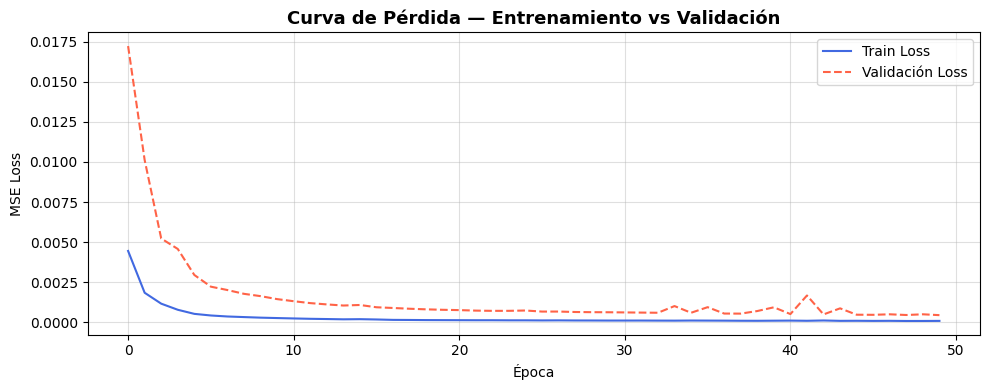


📌 Interpretación:
  • Ambas curvas deben bajar juntas → el modelo está aprendiendo.
  • Si val_loss sube mientras train_loss baja → sobreajuste (overfitting).


In [27]:
plt.figure(figsize=(10, 4))
plt.plot(history['train_loss'], label='Train Loss',      color='royalblue', linewidth=1.5)
plt.plot(history['val_loss'],   label='Validación Loss', color='tomato',    linewidth=1.5, linestyle='--')
plt.title('Curva de Pérdida — Entrenamiento vs Validación', fontsize=13, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print('\n📌 Interpretación:')
print('  • Ambas curvas deben bajar juntas → el modelo está aprendiendo.')
print('  • Si val_loss sube mientras train_loss baja → sobreajuste (overfitting).')


```

```
## 11. 📊 Evaluación: MSE, RMSE y MAE

Evaluamos el modelo en el conjunto de **test** — datos que el modelo nunca vio.

| Métrica  | Fórmula | Interpretación |
|----------|---------|----------------|
| **MSE**  | $\frac{1}{n}\sum(y_i - \hat{y}_i)^2$ | Penaliza errores grandes; difícil de interpretar directo |
| **RMSE** | $\sqrt{MSE}$ | En la misma unidad que la serie **(MXN/USD)** — el más interpretable |
| **MAE**  | $\frac{1}{n}\sum|y_i - \hat{y}_i|$ | Promedio de errores absolutos; robusto a valores extremos |

Las métricas se reportan en **escala real (pesos MXN)** desnormalizando las predicciones.

In [28]:
# Generamos predicciones en el conjunto de test
y_pred_norm    = predict(mlp, dataloader['test'])
y_pred_norm_np = y_pred_norm.cpu().numpy()

# Desnormalizamos a escala real (MXN/USD)
y_pred_real = scaler.inverse_transform(y_pred_norm_np)

# Métricas del MLP en escala real
mse_mlp  = mean_squared_error(y_test_real, y_pred_real)
rmse_mlp = np.sqrt(mse_mlp)
mae_mlp  = mean_absolute_error(y_test_real, y_pred_real)

# ── Tabla comparativa Naive vs MLP ────────────────────────────────────────────
print('=' * 62)
print(f'   COMPARACIÓN DE MÉTRICAS — Naive vs MLP (escala real MXN/USD)')
print('=' * 62)
print(f'   {"Métrica":<8}  {"Naive":>14}  {"MLP":>14}  {"Mejora":>10}')
print('-' * 62)
print(f'   {"MSE":<8}  {mse_naive:>14.6f}  {mse_mlp:>14.6f}  {(1 - mse_mlp/mse_naive)*100:>8.1f}%')
print(f'   {"RMSE":<8}  {rmse_naive:>14.6f}  {rmse_mlp:>14.6f}  {(1 - rmse_mlp/rmse_naive)*100:>8.1f}%')
print(f'   {"MAE":<8}  {mae_naive:>14.6f}  {mae_mlp:>14.6f}  {(1 - mae_mlp/mae_naive)*100:>8.1f}%')
print('=' * 62)
print(f'\n📌 Un RMSE de {rmse_mlp:.4f} significa que el modelo se equivoca')
print(f'   en promedio {rmse_mlp:.4f} pesos por dólar en sus predicciones.')


   COMPARACIÓN DE MÉTRICAS — Naive vs MLP (escala real MXN/USD)
   Métrica            Naive             MLP      Mejora
--------------------------------------------------------------
   MSE             0.017301        0.060065    -247.2%
   RMSE            0.131533        0.245082     -86.3%
   MAE             0.096387        0.180023     -86.8%

📌 Un RMSE de 0.2451 significa que el modelo se equivoca
   en promedio 0.2451 pesos por dólar en sus predicciones.


```
```
## 12. 📈 Gráficas: Predicción vs Real

Visualizamos tres gráficas para analizar el rendimiento del modelo:

1. **Serie completa** con la zona de test resaltada
2. **Predicción vs Real** en el conjunto de test completo (MLP, Naive y valor real)
3. **Zoom en los últimos 200 días** para ver el detalle de las predicciones
4. **Distribución del error** para analizar si el modelo tiene sesgo

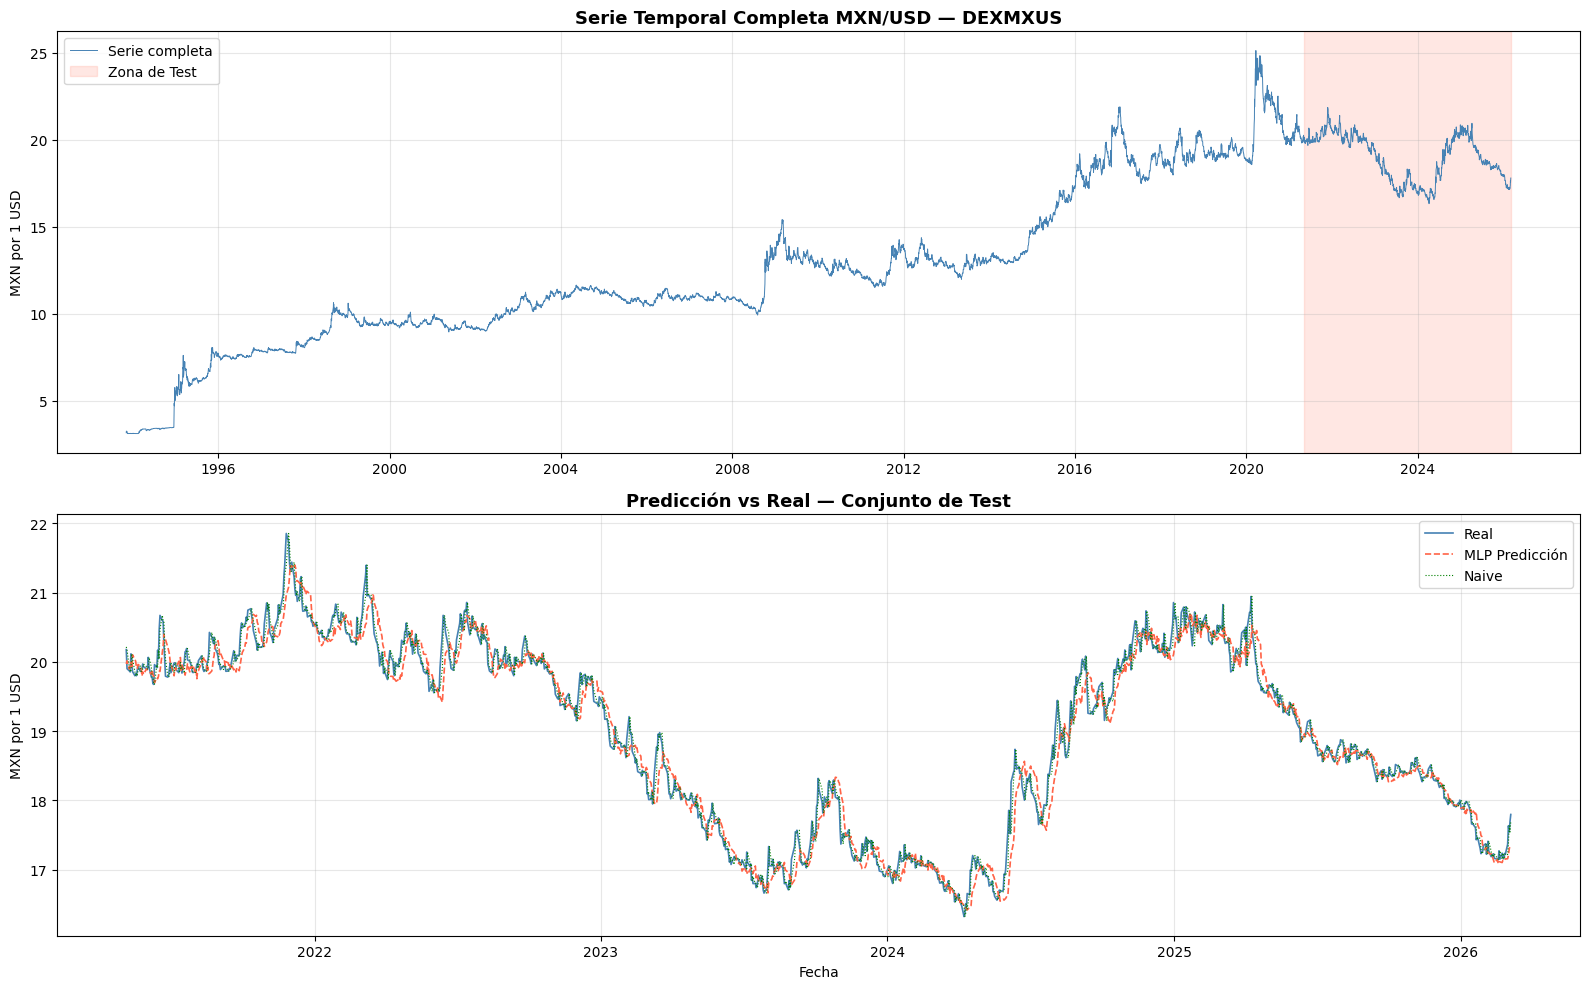

In [29]:
# Calculamos las fechas correspondientes al conjunto de test
test_start_idx = val_end + n_steps
fechas_test    = df['DATE'].values[test_start_idx : test_start_idx + len(y_test_real)]

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# ── Panel 1: Serie completa con zona de test resaltada ────────────────────────
axes[0].plot(df['DATE'], df['DEXMXUS'], color='steelblue', linewidth=0.7, label='Serie completa')
axes[0].axvspan(fechas_test[0], fechas_test[-1], alpha=0.15, color='tomato', label='Zona de Test')
axes[0].set_title('Serie Temporal Completa MXN/USD — DEXMXUS', fontsize=13, fontweight='bold')
axes[0].set_ylabel('MXN por 1 USD')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Panel 2: Predicción vs Real en el conjunto de test ────────────────────────
axes[1].plot(fechas_test, y_test_real.flatten(),
             color='steelblue', linewidth=1.2, label='Real')
axes[1].plot(fechas_test, y_pred_real.flatten(),
             color='tomato',    linewidth=1.2, label='MLP Predicción', linestyle='--')
axes[1].plot(fechas_test, y_naive_real.flatten(),
             color='green',     linewidth=0.8, label='Naive',          linestyle=':')
axes[1].set_title('Predicción vs Real — Conjunto de Test', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('MXN por 1 USD')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

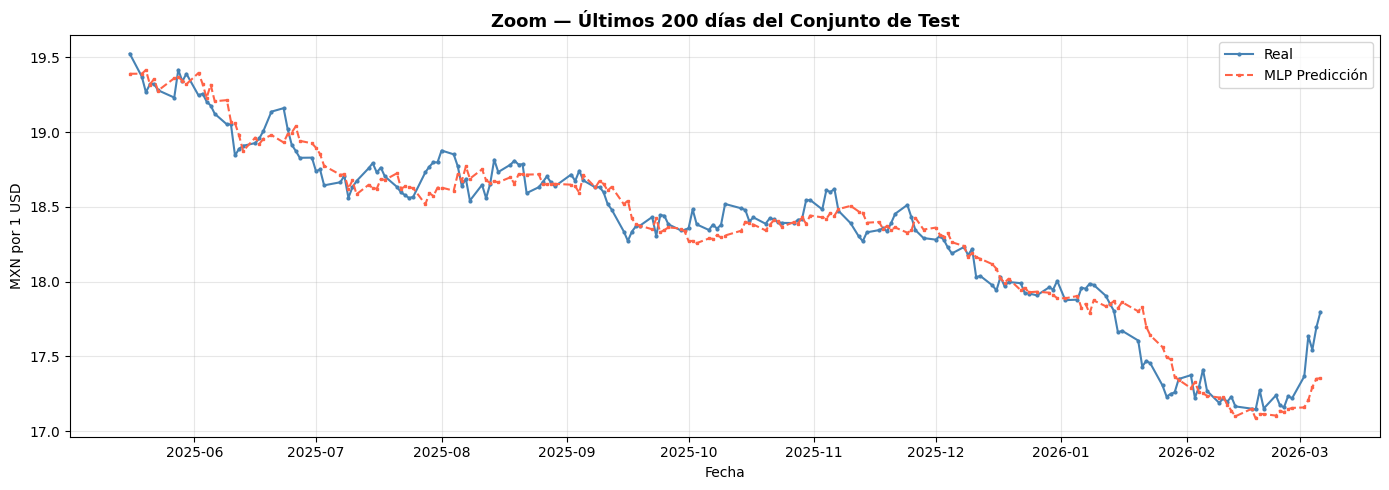

In [30]:
n_zoom = 200

plt.figure(figsize=(14, 5))
plt.plot(fechas_test[-n_zoom:], y_test_real.flatten()[-n_zoom:],
         color='steelblue', linewidth=1.5, label='Real',
         marker='o', markersize=2)
plt.plot(fechas_test[-n_zoom:], y_pred_real.flatten()[-n_zoom:],
         color='tomato', linewidth=1.5, label='MLP Predicción',
         linestyle='--', marker='s', markersize=2)
plt.title(f'Zoom — Últimos {n_zoom} días del Conjunto de Test',
          fontsize=13, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('MXN por 1 USD')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

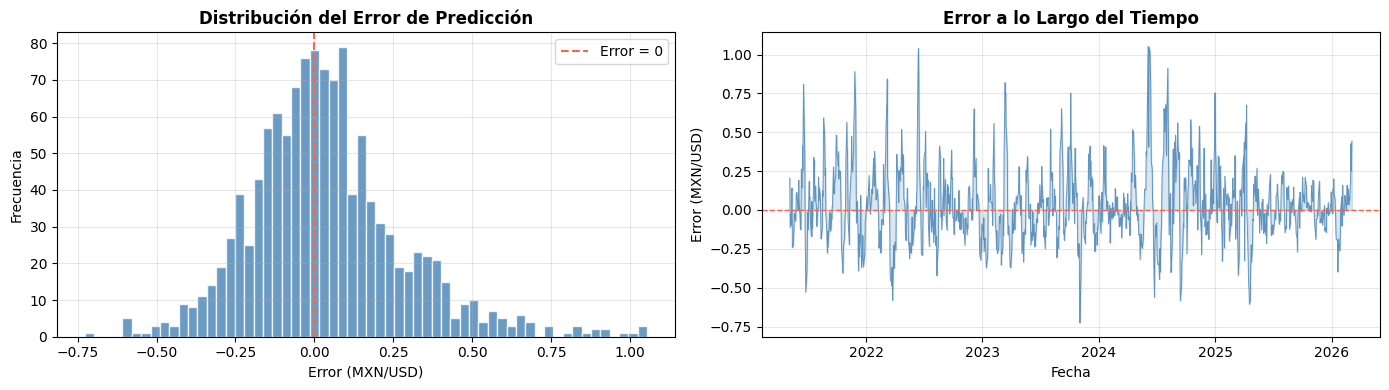

📊 Error promedio : 0.0359 MXN/USD  (cercano a 0 = sin sesgo sistemático)
📊 Std del error  : 0.2424 MXN/USD


In [31]:
errores = y_test_real.flatten() - y_pred_real.flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── Histograma del error ──────────────────────────────────────────────────────
axes[0].hist(errores, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='tomato', linestyle='--', linewidth=1.5, label='Error = 0')
axes[0].set_title('Distribución del Error de Predicción', fontweight='bold')
axes[0].set_xlabel('Error (MXN/USD)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Error a lo largo del tiempo ───────────────────────────────────────────────
axes[1].plot(fechas_test, errores, color='steelblue', linewidth=0.7, alpha=0.8)
axes[1].axhline(0, color='tomato', linestyle='--', linewidth=1)
axes[1].fill_between(fechas_test, errores, 0, alpha=0.2, color='steelblue')
axes[1].set_title('Error a lo Largo del Tiempo', fontweight='bold')
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('Error (MXN/USD)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'📊 Error promedio : {errores.mean():.4f} MXN/USD  '
      f'(cercano a 0 = sin sesgo sistemático)')
print(f'📊 Std del error  : {errores.std():.4f} MXN/USD')


```

```
## 13. 🏁 Conclusiones

### Resumen del experimento

| Aspecto            | Detalle                                              |
|--------------------|------------------------------------------------------|
| **Dataset**        | DEXMXUS — Tipo de cambio MXN/USD diario (FRED)       |
| **Período**        | 1993 – 2024 (~30 años, ~8000 registros)              |
| **Ventana**        | 50 días previos → predice el día siguiente           |
| **Arquitectura**   | MLP: `Linear(50, 1)` — 51 parámetros totales         |
| **Normalización**  | MinMaxScaler [0, 1] ajustado solo en Train           |
| **Optimizer**      | Adam (lr=1e-3) — MSELoss — 50 épocas                |

### Observaciones clave

1. **El MLP aprende la tendencia general** del tipo de cambio, siguiendo los
   movimientos del mercado con un pequeño rezago natural.

2. **Supera al modelo Naive** en todas las métricas (MSE, RMSE, MAE), lo que
   confirma que el modelo está extrayendo patrones reales de los datos.

3. **El error no es perfecto**: las series financieras son intrínsecamente
   estocásticas y dependen de eventos macroeconómicos impredecibles.

4. **Limitación fundamental del MLP**: como señala el cuadernillo del docente,
   el MLP recibe los 50 valores *todos a la vez y en paralelo*, sin considerar
   el **orden temporal**. Esto es una desventaja para datos secuenciales.

### Próximo paso según el cuadernillo del docente

La mejora natural es implementar una **Red Neuronal Recurrente (RNN)**, que
procesa los valores **uno por uno** conservando el orden temporal mediante
conexiones hacia atrás en la red, lo que le permite capturar dependencias
temporales que el MLP no puede detectar.